# Section 6 - Python Data Processing: Cleaning Pipeline and Consolidated Dataset

This notebook is the canonical cleaning pipeline for the NorthStar dataset. It addresses Stage 1 problems P1, P2, and P5 by applying systematic cleaning, integrity flagging, and consolidated joining, and writes cleaned outputs to `data/cleaned/` for consumption by the MongoDB sections (7 and 8).

| § | Workflow deliverable | Stage 1 problem |
|---|---|---|
| 6.3 | Import all 9 CSVs + integrity audit | — |
| 6.4 | Cleaning pipeline (zones, timestamps, missing values) | **P1, P2, P5** |
| 6.5 | Derive `true_outcome` field | **P3 (architectural)** |
| 6.6 | Build consolidated dataframe | — |
| 6.7 | Save cleaned files to `data/cleaned/` | reproducibility |
| 6.8 | Descriptive statistics with Pandas + NumPy | workflow #4 |
| 6.9 | Pairwise plots | workflow #5 |

## 6.2 : Library Imports and Configuration

In [1]:
# 6.2 : Library imports

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
sns.set_style("whitegrid")

# Base URL for raw data
BASE_URL = "https://raw.githubusercontent.com/fathimathzahrahei/northstar-databases-analytics_dba_coursework/main/data/raw/"

# Output directory for cleaned files (Colab-local; mirrored to GitHub at end)
OUTPUT_DIR = "/content/cleaned"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Libraries loaded. Base URL:", BASE_URL)
print("Cleaned-output directory:", OUTPUT_DIR)

Libraries loaded. Base URL: https://raw.githubusercontent.com/fathimathzahrahei/northstar-databases-analytics_dba_coursework/main/data/raw/
Cleaned-output directory: /content/cleaned


## 6.3 : Importing CSVs and Verifying Data Integrity

The workflow specifies three steps for the CSV-import deliverable:
1. Import the file into a Pandas dataframe
2. Verify that the import preserved all rows
3. Confirm no duplication or loss

The cell below performs all three for every NorthStar table.

In [2]:
# 6.3 : Import every CSV and verify integrity

table_names = ['hubs', 'customers', 'drivers', 'vehicles',
               'orders', 'deliveries', 'incidents',
               'complaints', 'app_events']

# Expected row counts (from data dictionary / audit notebook)
expected = {'hubs': 8, 'customers': 650, 'drivers': 170, 'vehicles': 120,
            'orders': 1250, 'deliveries': 950, 'incidents': 280,
            'complaints': 320, 'app_events': 640}

dfs = {}
print(f"{'Table':<12} {'Rows':>6} {'Expected':>9} {'Cols':>5} {'PK duplicates':>14} {'Status':>10}")
print("-" * 65)
for name in table_names:
    df = pd.read_csv(BASE_URL + name + ".csv")
    dfs[name] = df

    # Check primary-key uniqueness (first column is always the PK)
    pk_col = df.columns[0]
    pk_dups = df[pk_col].duplicated().sum()

    status = "OK" if (len(df) == expected[name] and pk_dups == 0) else "CHECK"
    print(f"{name:<12} {len(df):>6} {expected[name]:>9} {df.shape[1]:>5} {pk_dups:>14} {status:>10}")

print("\nAll tables imported and integrity-checked.")

Table          Rows  Expected  Cols  PK duplicates     Status
-----------------------------------------------------------------
hubs              8         8     5              0         OK
customers       650       650     9              0         OK
drivers         170       170     8              0         OK
vehicles        120       120     8              0         OK
orders         1250      1250    11              0         OK
deliveries      950       950    13              0         OK
incidents       280       280     7              0         OK
complaints      320       320    10              0         OK
app_events      640       640    10              0         OK

All tables imported and integrity-checked.


## 6.4 : Cleaning Pipeline

The cleaning pipeline applies four operations in sequence:

1. **Standardise zone codes** across all six zone-bearing fields (orders, customers, drivers, vehicles, app_events) using an explicit mapping dictionary. This resolves Stage 1 Problem 1.

2. **Type-cast timestamps** and flag logical impossibilities. Deliveries whose `delivery_completed_at` precedes their `dispatch_time` are tagged with `integrity_flag = 'TIMESTAMP_IMPOSSIBLE'` rather than dropped, so the volume of integrity failure remains visible.

3. **Handle missing values** column-by-column with strategies appropriate to each variable.

4. **Add a derived `dispatch_to_completion_minutes` column** for downstream duration analysis.

In [3]:
# 6.4 a) Standardise zone codes across all six tables

zone_map = {
    'AIRPORT': 'Airport',  'Airport': 'Airport',
    'CENTRAL': 'Central',  'Central': 'Central',  'Ctr': 'Central',
    'EAST':    'East',     'East':    'East',
    'NORTH':   'North',    'North':   'North',    'north': 'North',
    'RiverSide': 'Riverside', 'Riverside': 'Riverside',
    'SOUTH':   'South',    'South':   'South',
    'WEST':    'West',     'West':    'West'
}

# Apply mapping to every zone-bearing field
zone_fields = [
    ('orders',     'pickup_zone'),
    ('orders',     'dropoff_zone'),
    ('customers',  'home_zone'),
    ('drivers',    'base_zone'),
    ('vehicles',   'assigned_zone'),
    ('app_events', 'zone_context')
]

print("Zone standardisation results:")
print(f"{'Table.Field':<28} {'Before':>8} {'After':>8}")
print("-" * 50)
for table, field in zone_fields:
    before = dfs[table][field].nunique()
    dfs[table][field] = dfs[table][field].map(zone_map).fillna(dfs[table][field])
    after = dfs[table][field].nunique()
    print(f"{table+'.'+field:<28} {before:>8} {after:>8}")

print("\nAll six fields now use the canonical 7-zone vocabulary.")

Zone standardisation results:
Table.Field                    Before    After
--------------------------------------------------
orders.pickup_zone                 16        7
orders.dropoff_zone                16        7
customers.home_zone                16        7
drivers.base_zone                  16        7
vehicles.assigned_zone             16        7
app_events.zone_context            16        7

All six fields now use the canonical 7-zone vocabulary.


In [4]:
# 6.4 b) Cast timestamps and flag logical impossibilities

dfs['deliveries']['dispatch_time'] = pd.to_datetime(
    dfs['deliveries']['dispatch_time'], errors='coerce')
dfs['deliveries']['delivery_completed_at'] = pd.to_datetime(
    dfs['deliveries']['delivery_completed_at'], errors='coerce')

# Compute duration where both timestamps exist
dfs['deliveries']['dispatch_to_completion_minutes'] = (
    (dfs['deliveries']['delivery_completed_at']
     - dfs['deliveries']['dispatch_time']).dt.total_seconds() / 60
)

# Add integrity flag
dfs['deliveries']['integrity_flag'] = 'OK'
mask_impossible = (
    dfs['deliveries']['delivery_completed_at'].notna()
    & dfs['deliveries']['dispatch_time'].notna()
    & (dfs['deliveries']['delivery_completed_at']
       < dfs['deliveries']['dispatch_time'])
)
dfs['deliveries'].loc[mask_impossible, 'integrity_flag'] = 'TIMESTAMP_IMPOSSIBLE'

# Cast other date columns
for table, col in [('orders','order_created_at'), ('complaints','created_at'),
                   ('incidents','reported_at'), ('app_events','event_timestamp'),
                   ('customers','signup_date'), ('vehicles','commission_date')]:
    dfs[table][col] = pd.to_datetime(dfs[table][col], errors='coerce')

print("Integrity-flag distribution:")
print(dfs['deliveries']['integrity_flag'].value_counts())
print(f"\n{mask_impossible.sum()} deliveries flagged as TIMESTAMP_IMPOSSIBLE")
print(f"({mask_impossible.sum() / len(dfs['deliveries']) * 100:.1f}% of all deliveries)")

Integrity-flag distribution:
integrity_flag
OK                      886
TIMESTAMP_IMPOSSIBLE     64
Name: count, dtype: int64

64 deliveries flagged as TIMESTAMP_IMPOSSIBLE
(6.7% of all deliveries)


In [5]:
# 6.4 c) Handle missing values column-by-column

print("Missing-value treatment:")
print("-" * 70)

# customers.loyalty_score - numeric, low miss rate → median imputation
n_before = dfs['customers']['loyalty_score'].isna().sum()
median_loyalty = dfs['customers']['loyalty_score'].median()
dfs['customers']['loyalty_score'] = dfs['customers']['loyalty_score'].fillna(median_loyalty)
print(f"customers.loyalty_score:           imputed {n_before} with median ({median_loyalty:.1f})")

# customers.preferred_channel - categorical → 'Unknown'
n_before = dfs['customers']['preferred_channel'].isna().sum()
dfs['customers']['preferred_channel'] = dfs['customers']['preferred_channel'].fillna('Unknown')
print(f"customers.preferred_channel:       filled {n_before} with 'Unknown'")

# drivers.training_score - group-median by base_zone
n_before = dfs['drivers']['training_score'].isna().sum()
dfs['drivers']['training_score'] = dfs['drivers'].groupby('base_zone')['training_score']\
    .transform(lambda x: x.fillna(x.median()))
print(f"drivers.training_score:            imputed {n_before} with zone-median")

# vehicles.battery_health_pct - median imputation
n_before = dfs['vehicles']['battery_health_pct'].isna().sum()
median_batt = dfs['vehicles']['battery_health_pct'].median()
dfs['vehicles']['battery_health_pct'] = dfs['vehicles']['battery_health_pct'].fillna(median_batt)
print(f"vehicles.battery_health_pct:       imputed {n_before} with median ({median_batt:.1f}%)")

# orders.booking_channel - 'Unknown'
n_before = dfs['orders']['booking_channel'].isna().sum()
dfs['orders']['booking_channel'] = dfs['orders']['booking_channel'].fillna('Unknown')
print(f"orders.booking_channel:            filled {n_before} with 'Unknown'")

# deliveries.customer_rating_post_delivery - left as NaN (means no rating given)
n_remaining = dfs['deliveries']['customer_rating_post_delivery'].isna().sum()
print(f"deliveries.customer_rating:        left {n_remaining} as NaN (no rating given)")

# incidents.resolved_hours - group-median by severity
n_before = dfs['incidents']['resolved_hours'].isna().sum()
dfs['incidents']['resolved_hours'] = dfs['incidents'].groupby('severity')['resolved_hours']\
    .transform(lambda x: x.fillna(x.median()))
print(f"incidents.resolved_hours:          imputed {n_before} with severity-median")

# complaints.compensation_amount - fill with 0 (assume no comp paid)
n_before = dfs['complaints']['compensation_amount'].isna().sum()
dfs['complaints']['compensation_amount'] = dfs['complaints']['compensation_amount'].fillna(0)
print(f"complaints.compensation_amount:    filled {n_before} with 0")

# app_events.order_id - left as NaN (structural, not erroneous)
n_remaining = dfs['app_events']['order_id'].isna().sum()
print(f"app_events.order_id:               left {n_remaining} as NaN (structural — not all events relate to an order)")

print("\nAll missing-value strategies applied.")

Missing-value treatment:
----------------------------------------------------------------------
customers.loyalty_score:           imputed 20 with median (59.6)
customers.preferred_channel:       filled 13 with 'Unknown'
drivers.training_score:            imputed 7 with zone-median
vehicles.battery_health_pct:       imputed 4 with median (78.0%)
orders.booking_channel:            filled 25 with 'Unknown'
deliveries.customer_rating:        left 14 as NaN (no rating given)
incidents.resolved_hours:          imputed 17 with severity-median
complaints.compensation_amount:    filled 16 with 0
app_events.order_id:               left 144 as NaN (structural — not all events relate to an order)

All missing-value strategies applied.


## 6.5 : Derive the `true_outcome` Field (Problem 3)

The `true_outcome` field reconciles the operational system's `delivery_status` with customer complaint signal. A delivery is reported as `OnTime` only if the operational status is `OnTime` AND no high-severity complaint is attached to the same `order_id`. Otherwise it carries the operational status, or `OnTime_with_complaint` for the hidden-failure cases.

In [6]:
# 6.5 : Derive true_outcome on the deliveries table

# Build a lookup of order_ids that have at least one HIGH-severity complaint
high_severity_orders = set(
    dfs['complaints']
    .loc[dfs['complaints']['severity'] == 'High', 'order_id']
    .dropna().unique()
)

dfs['deliveries']['true_outcome'] = dfs['deliveries']['delivery_status']
mask_hidden = (
    (dfs['deliveries']['delivery_status'] == 'OnTime')
    & (dfs['deliveries']['order_id'].isin(high_severity_orders))
)
dfs['deliveries'].loc[mask_hidden, 'true_outcome'] = 'OnTime_with_complaint'

print("True-outcome distribution:")
print(dfs['deliveries']['true_outcome'].value_counts())

print(f"\n{mask_hidden.sum()} deliveries reclassified as 'OnTime_with_complaint'")
print(f"(formerly OnTime, but received a HIGH-severity complaint)")

True-outcome distribution:
true_outcome
OnTime                   588
Delayed                  202
Failed                   132
OnTime_with_complaint     28
Name: count, dtype: int64

28 deliveries reclassified as 'OnTime_with_complaint'
(formerly OnTime, but received a HIGH-severity complaint)


## 6.6 : Building the Consolidated Dataframe (Workflow #2)

The workflow asks for a single consolidated dataframe combining multiple files. The build joins orders + deliveries + customers + complaint-summary into one analytical row per order, ensuring no row loss.

In [7]:
# 6.6 : Build a consolidated, analysis-ready dataframe

# Step 1: orders + deliveries (left-join keeps all orders, even cancelled ones)
master = dfs['orders'].merge(
    dfs['deliveries'],
    on='order_id', how='left', suffixes=('_ord', '_del')
)
print(f"After orders + deliveries: {len(master)} rows (expected {len(dfs['orders'])})")

# Step 2: + customers
master = master.merge(dfs['customers'], on='customer_id', how='left')
print(f"After + customers:         {len(master)} rows")

# Step 3: + complaint summary (one complaint row per order_id may not be enough,
# so we aggregate complaints by order_id first)
complaint_summary = dfs['complaints'].groupby('order_id').agg(
    complaint_count=('complaint_id', 'count'),
    has_high_severity=('severity', lambda s: (s == 'High').any()),
    total_compensation=('compensation_amount', 'sum')
).reset_index()

master = master.merge(complaint_summary, on='order_id', how='left')
master['has_complaint']     = master['complaint_count'].notna()
master['complaint_count']   = master['complaint_count'].fillna(0).astype(int)
master['has_high_severity'] = master['has_high_severity'].fillna(False)
master['total_compensation'] = master['total_compensation'].fillna(0)
print(f"After + complaint summary: {len(master)} rows")

# Verify no row loss
assert len(master) == len(dfs['orders']), "Row count mismatch!"
print("\nConsolidated dataframe built successfully, no row loss.")
print(f"\nFinal shape: {master.shape}")
print(f"Columns: {master.shape[1]}")

After orders + deliveries: 1250 rows (expected 1250)
After + customers:         1250 rows
After + complaint summary: 1250 rows

Consolidated dataframe built successfully, no row loss.

Final shape: (1250, 38)
Columns: 38


/tmp/ipykernel_6297/2425506140.py:25: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  master['has_high_severity'] = master['has_high_severity'].fillna(False)


## 6.7 : Save Cleaned Files to data/cleaned/

The cleaned tables are written to disk (Colab session storage). These files become the canonical input for the MongoDB sections (7 and 8).

In [8]:
# 6.7 : Save cleaned tables and the consolidated dataframe to /content/cleaned/

for name, df in dfs.items():
    path = os.path.join(OUTPUT_DIR, f"{name}_clean.csv")
    df.to_csv(path, index=False)
    print(f"  Saved {path:<50} ({len(df)} rows)")

master_path = os.path.join(OUTPUT_DIR, "master_consolidated.csv")
master.to_csv(master_path, index=False)
print(f"  Saved {master_path:<50} ({len(master)} rows)")

print(f"\nAll cleaned files written to {OUTPUT_DIR}")
print("These files should be uploaded to data/cleaned/ in the GitHub repository.")

  Saved /content/cleaned/hubs_clean.csv                    (8 rows)
  Saved /content/cleaned/customers_clean.csv               (650 rows)
  Saved /content/cleaned/drivers_clean.csv                 (170 rows)
  Saved /content/cleaned/vehicles_clean.csv                (120 rows)
  Saved /content/cleaned/orders_clean.csv                  (1250 rows)
  Saved /content/cleaned/deliveries_clean.csv              (950 rows)
  Saved /content/cleaned/incidents_clean.csv               (280 rows)
  Saved /content/cleaned/complaints_clean.csv              (320 rows)
  Saved /content/cleaned/app_events_clean.csv              (640 rows)
  Saved /content/cleaned/master_consolidated.csv           (1250 rows)

All cleaned files written to /content/cleaned
These files should be uploaded to data/cleaned/ in the GitHub repository.


## 6.8 : Descriptive Statistics (Workflow #4)

Summary statistics for all numerical columns in the consolidated dataframe - mean, median, standard deviation, min, max, and quartiles  using Pandas + NumPy.

In [9]:
# 6.8 : Descriptive statistics with Pandas + NumPy

numerical_cols = [
    'order_value', 'route_distance_km', 'fuel_or_charge_cost',
    'manual_route_override_count', 'promised_window_hours',
    'dispatch_to_completion_minutes', 'loyalty_score',
    'app_engagement_score', 'complaint_count', 'total_compensation'
]

stats_table = master[numerical_cols].describe(percentiles=[0.25, 0.5, 0.75]).T
stats_table['skewness'] = master[numerical_cols].skew().round(2)
stats_table = stats_table.round(2)

print("Descriptive statistics for the consolidated dataframe:")
print(stats_table)

# Some highlights with NumPy
print(f"\nKey aggregates (using NumPy):")
print(f"  Total revenue (orders + deliveries):   £{np.nansum(master['order_value']):,.2f}")
print(f"  Total compensation paid:                £{np.nansum(master['total_compensation']):,.2f}")
print(f"  Mean delivery duration:                {np.nanmean(master['dispatch_to_completion_minutes']):.1f} minutes")
print(f"  Median override count per delivery:    {np.nanmedian(master['manual_route_override_count']):.0f}")

Descriptive statistics for the consolidated dataframe:
                                 count    mean     std     min     25%     50%     75%      max  skewness
order_value                     1250.0   91.05   60.92    2.04   47.92   76.53  121.10   510.06      1.35
route_distance_km                950.0   13.91    7.48    1.20    9.14   12.84   16.84    41.94      1.05
fuel_or_charge_cost              950.0   12.84    4.34    2.50    9.93   12.64   15.70    29.43      0.24
manual_route_override_count      950.0    0.97    1.09    0.00    0.00    1.00    2.00     7.00      1.29
promised_window_hours           1250.0    7.62    7.06    1.00    4.00    6.00   12.00    24.00      1.44
dispatch_to_completion_minutes   931.0  572.73  518.92 -132.87  176.75  424.46  878.62  2607.42      1.03
loyalty_score                   1250.0   59.84   15.53   14.50   49.30   59.60   69.80    99.00      0.11
app_engagement_score            1250.0   57.77   18.62    1.00   44.72   58.20   71.30   100.00  

## 6.9 : Pairwise Plots for Numerical Features (Workflow #5)

Three plot types as required by the workflow:
1. Scatter plot of one chosen pair (order value vs route distance)
2. Pair plot: all pairwise relationships at once
3. Correlation heatmap: numerical equivalent of a pair plot

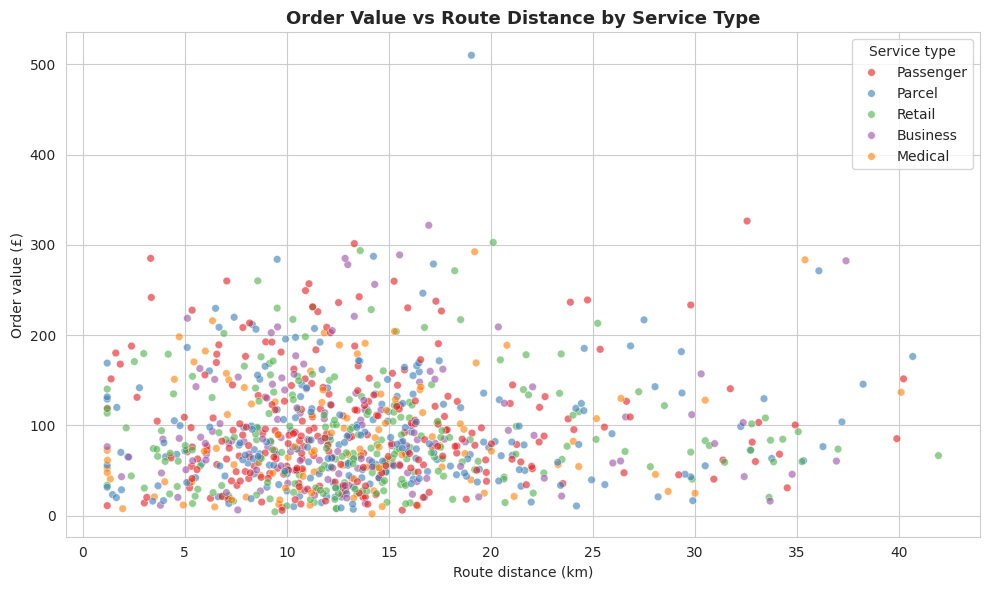

In [10]:
# 6.9 a) Plot 1: scatter of order_value vs route_distance_km, hued by service_type

plot_df = master.dropna(subset=['order_value', 'route_distance_km', 'service_type'])
plot_df = plot_df[(plot_df['route_distance_km'] > 0) & (plot_df['order_value'] > 0)]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_df, x='route_distance_km', y='order_value',
                hue='service_type', alpha=0.6, s=30, palette='Set1')
plt.title('Order Value vs Route Distance by Service Type', fontsize=13, fontweight='bold')
plt.xlabel('Route distance (km)')
plt.ylabel('Order value (£)')
plt.legend(title='Service type', loc='upper right')
plt.tight_layout()
plt.savefig('plot_py_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

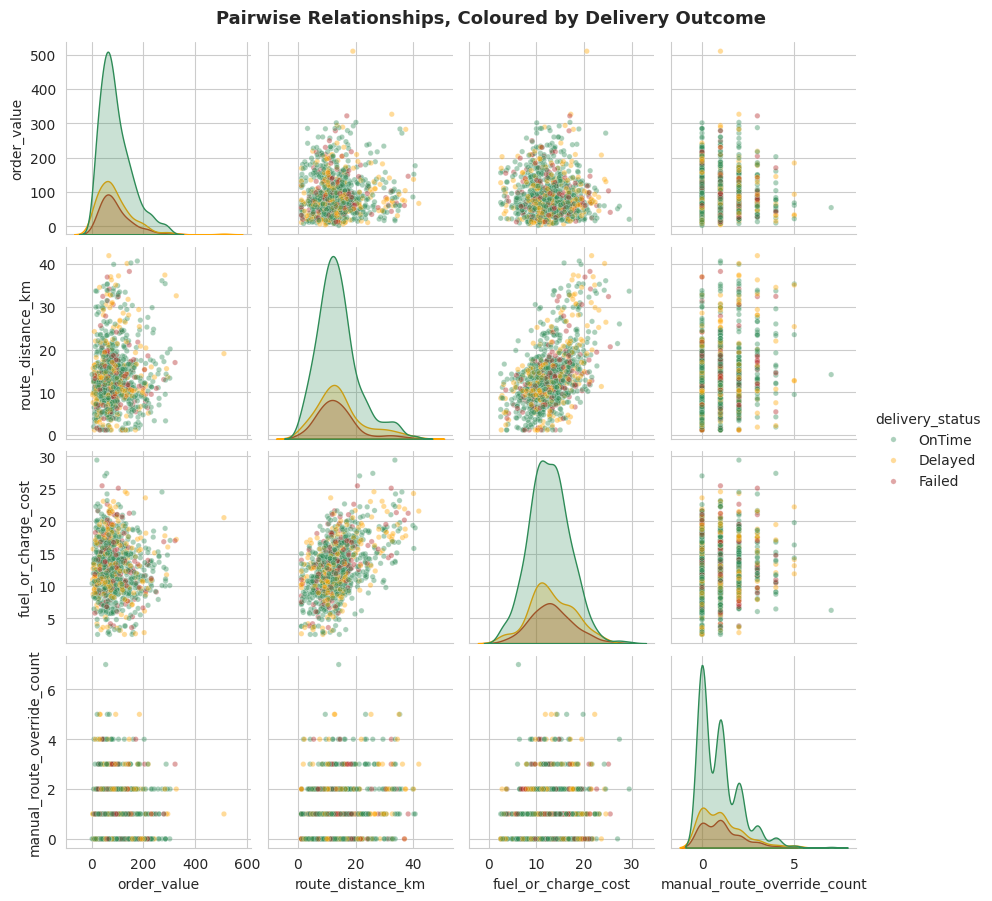

In [11]:
# 6.9 b) Plot 2: seaborn pair plot of four key numerical features

pair_cols = ['order_value', 'route_distance_km',
             'fuel_or_charge_cost', 'manual_route_override_count']

pair_df = master[pair_cols + ['delivery_status']].dropna()

g = sns.pairplot(pair_df,
                 vars=pair_cols,
                 hue='delivery_status',
                 palette={'OnTime': '#2E8B57', 'Delayed': '#FFA500',
                          'Failed': '#B22222'},
                 plot_kws={'alpha': 0.4, 's': 15},
                 diag_kind='kde',
                 height=2.2)
g.fig.suptitle('Pairwise Relationships, Coloured by Delivery Outcome',
               y=1.02, fontsize=13, fontweight='bold')
plt.savefig('plot_py_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

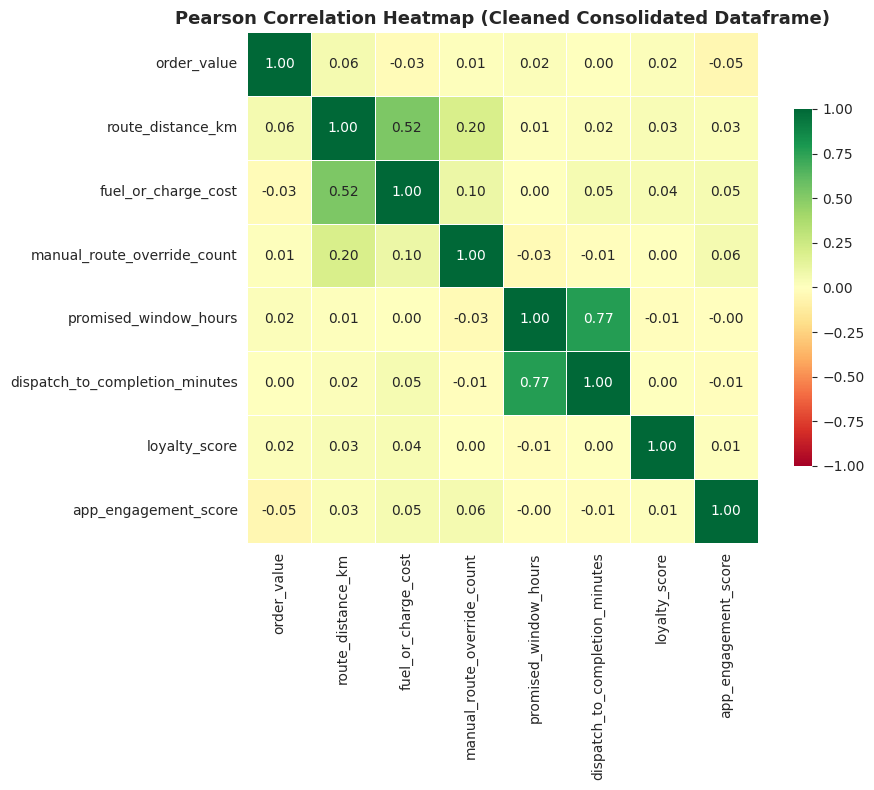

In [12]:
# 6.9 c) Plot 3: correlation heatmap of all numerical features

corr_cols = ['order_value', 'route_distance_km', 'fuel_or_charge_cost',
             'manual_route_override_count', 'promised_window_hours',
             'dispatch_to_completion_minutes', 'loyalty_score',
             'app_engagement_score']

corr = master[corr_cols].corr(method='pearson')

plt.figure(figsize=(10, 8))
sns.heatmap(corr,
            annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.7})
plt.title('Pearson Correlation Heatmap (Cleaned Consolidated Dataframe)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_py_corr.png', dpi=150, bbox_inches='tight')
plt.show()

## Section Summary

This notebook implemented the canonical NorthStar cleaning pipeline:

- **Problem 1** (zone fragmentation) : resolved by mapping 16 spellings to 7 canonical values across all 6 zone-bearing fields
- **Problem 2** (timestamp impossibilities) : 64 deliveries flagged with `integrity_flag = 'TIMESTAMP_IMPOSSIBLE'`
- **Problem 5** (missing values) : 10 columns handled with column-specific strategies
- **Problem 3** (hidden complaints) : `true_outcome` field surfaces 28 OnTime-with-high-severity-complaint cases at the delivery row level

Cleaned files written to `/content/cleaned/`:
- 9 individual cleaned tables (`*_clean.csv`)
- 1 consolidated `master_consolidated.csv` for analytical use

Three pairwise plots produced (scatter, pair plot, correlation heatmap).

The cleaned files become the input for Section 7 (MongoDB Atlas).

In [14]:
# 6.9 d) Zip the cleaned folder for download

import shutil
shutil.make_archive('/content/cleaned_files', 'zip', '/content/cleaned')
print("Zip created at /content/cleaned_files.zip")
print("Right-click it in the Files sidebar → Download")

Zip created at /content/cleaned_files.zip
Right-click it in the Files sidebar → Download
